In [119]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, confusion_matrix,f1_score,precision_score,recall_score
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from mlxtend.plotting import plot_decision_regions

In [120]:
df=pd.read_csv("Placement.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Student_ID  100 non-null    int64  
 1   CGPA        100 non-null    float64
 2   IQ          100 non-null    int64  
 3   Placement   100 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 3.3 KB


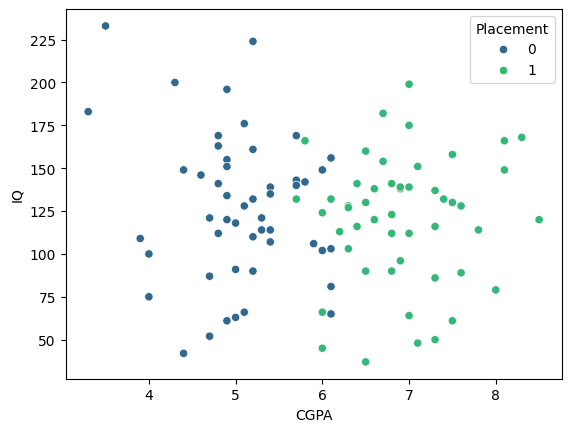

In [121]:
sns.scatterplot(data=df,x="CGPA",y="IQ",hue="Placement",palette="viridis")
plt.show()

In [122]:
x=df[["CGPA","IQ"]]
y=df["Placement"]

In [123]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=8)

In [124]:
lr=LogisticRegression()
lr.fit(x_train,y_train)
lr.score(x_test,y_test)

0.9

C:\Users\mitad\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


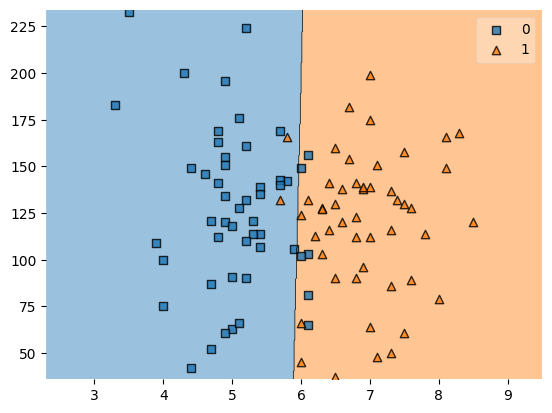

In [125]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=lr)
plt.show()

In [126]:
np.sqrt(mean_squared_error(y_test, lr.predict(x_test)))

np.float64(0.31622776601683794)

In [127]:
lr.predict([[6,180]])

C:\Users\mitad\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

CONFUSION MATRIX

In [128]:
cm=confusion_matrix(y_test,lr.predict(x_test))

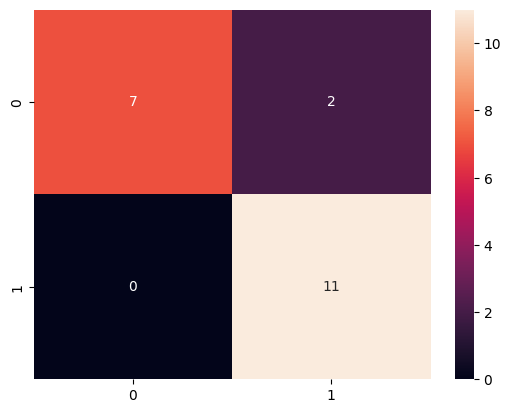

In [129]:
sns.heatmap(data=cm, annot=True)
plt.show()

In [130]:
precision_score(y_test,lr.predict(x_test))

0.8461538461538461

In [131]:
recall_score(y_test,lr.predict(x_test))

1.0

In [132]:
f1_score(y_test,lr.predict(x_test))

0.9166666666666666